In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [119]:
df = pd.read_csv('ml_features.csv')
print(df.shape)
df.head()

(179106, 11)


,user_id,ride_date,ride_hour,distance_km,surge_multiplier,estimated_duration_min,driver_rating,city,event_type,user_segment,is_cancelled
0,U_4880,2024-10-18,16,7.96,1.00,23,4.4,Bangalore,normal,regular,0
1,U_2514,2025-04-03,14,2.31,1.00,6,4.0,Mumbai,festival,regular,0
2,U_6708,2024-10-23,8,17.51,1.43,52,4.4,Jaipur,rain,regular,0
3,U_10977,2025-06-24,0,7.48,1.00,22,4.7,Hyderabad,rain,regular,0
4,U_5484,2025-06-28,0,13.67,1.00,41,4.4,Jaipur,festival,regular,0


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179106 entries, 0 to 179105
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   user_id                 179106 non-null  object 
 1   ride_date               179106 non-null  object 
 2   ride_hour               179106 non-null  int64  
 3   distance_km             179106 non-null  float64
 4   surge_multiplier        179106 non-null  float64
 5   estimated_duration_min  179106 non-null  int64  
 6   driver_rating           179106 non-null  float64
 7   city                    179106 non-null  object 
 8   event_type              179106 non-null  object 
 9   user_segment            179106 non-null  object 
 10  is_cancelled            179106 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 15.0+ MB


In [121]:
df.isnull().sum()

user_id                   0
ride_date                 0
ride_hour                 0
distance_km               0
surge_multiplier          0
estimated_duration_min    0
driver_rating             0
city                      0
event_type                0
user_segment              0
is_cancelled              0
dtype: int64

In [122]:
df.duplicated().sum()

np.int64(0)

In [123]:
df.describe()

,ride_hour,distance_km,surge_multiplier,estimated_duration_min,driver_rating,is_cancelled
count,179106.000000,179106.000000,179106.00000,179106.000000,179106.000000,179106.000000
mean,6.940639,10.590873,1.21435,31.272693,4.401246,0.127204
std,7.538858,9.734904,0.32697,29.203667,0.692472,0.333202
min,0.000000,0.010000,1.00000,0.000000,0.000000,0.000000
25%,0.000000,4.430000,1.00000,13.000000,4.300000,0.000000
50%,6.000000,6.950000,1.00000,20.000000,4.500000,0.000000
75%,14.000000,13.910000,1.47000,41.000000,4.700000,0.000000
max,23.000000,50.000000,2.00000,149.000000,5.000000,1.000000


**estimated_duration_min should not be 0 and driver rating need to change**

In [124]:
df = df[df['estimated_duration_min']>0]

In [125]:
df.describe()

,ride_hour,distance_km,surge_multiplier,estimated_duration_min,driver_rating,is_cancelled
count,178478.000000,178478.000000,178478.000000,178478.000000,178478.000000,178478.000000
mean,6.941578,10.627527,1.214403,31.382731,4.401252,0.127142
std,7.539154,9.732349,0.326997,29.195921,0.692354,0.333133
min,0.000000,0.330000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,4.460000,1.000000,13.000000,4.300000,0.000000
50%,6.000000,6.960000,1.000000,20.000000,4.500000,0.000000
75%,14.000000,13.940000,1.470000,41.000000,4.700000,0.000000
max,23.000000,50.000000,2.000000,149.000000,5.000000,1.000000


In [126]:
rat_mean = df['driver_rating'].mean()
rat_med = df['driver_rating'].median()
rat_mode = df['driver_rating'].mode()

print(rat_mean, rat_med, rat_mode)

4.401251694886765 4.5 0    4.4
Name: driver_rating, dtype: float64


In [127]:
df['driver_rating'].value_counts()

driver_rating
4.4    22914
4.5    21782
4.6    19364
4.7    19193
4.3    18995
4.2    14277
4.8    14256
5.0    12170
4.1    10142
4.9     9705
4.0     6001
0.0     3561
3.9     3078
3.8     1874
3.7      614
3.6      253
3.5      185
3.4      114
Name: count, dtype: int64

In [128]:
df['driver_rating'] = df['driver_rating'].replace(0, df['driver_rating'].mode()[0])

In [129]:
df['driver_rating'].dtype

dtype('float64')

In [130]:
df.describe()

,ride_hour,distance_km,surge_multiplier,estimated_duration_min,driver_rating,is_cancelled
count,178478.000000,178478.000000,178478.000000,178478.000000,178478.000000,178478.000000
mean,6.941578,10.627527,1.214403,31.382731,4.489041,0.127142
std,7.539154,9.732349,0.326997,29.195921,0.291810,0.333133
min,0.000000,0.330000,1.000000,1.000000,3.400000,0.000000
25%,0.000000,4.460000,1.000000,13.000000,4.300000,0.000000
50%,6.000000,6.960000,1.000000,20.000000,4.500000,0.000000
75%,14.000000,13.940000,1.470000,41.000000,4.700000,0.000000
max,23.000000,50.000000,2.000000,149.000000,5.000000,1.000000


In [131]:
## Feature Engineering

In [132]:
df['is_peak_hour'] = df['ride_hour'].isin([8,21]).astype(int)

In [133]:
df['ride_date'] = pd.to_datetime(df['ride_date'])
df['day_of_week'] = df['ride_date'].dt.day_name()

In [134]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

In [135]:
def surge_bucket(x):
    if x ==1:
        return 'no_surge'
    elif x<=1.5:
        return 'low_surge'
    else:
        return 'high_surge'

df['surge_bucket'] = df['surge_multiplier'].apply(surge_bucket)

In [136]:
def driver_seg(x):
    if x==3.5:
        return 'low'
    elif x<=4.5:
        return 'medium'
    else:
        return 'high'

df['driver_seg'] = df['driver_rating'].apply(driver_seg)

In [137]:
df['distance_bucket'] = pd.cut(df['distance_km'], bins=[0,2,15,50], labels=['short', 'medium,', 'long'])

In [138]:
df['high_risk_combo'] = ((df['is_peak_hour']==1)&
                         (df['surge_bucket'] =='high')&
                         (df['distance_bucket']=='short')).astype(int)

**Surge vs Cancellation**

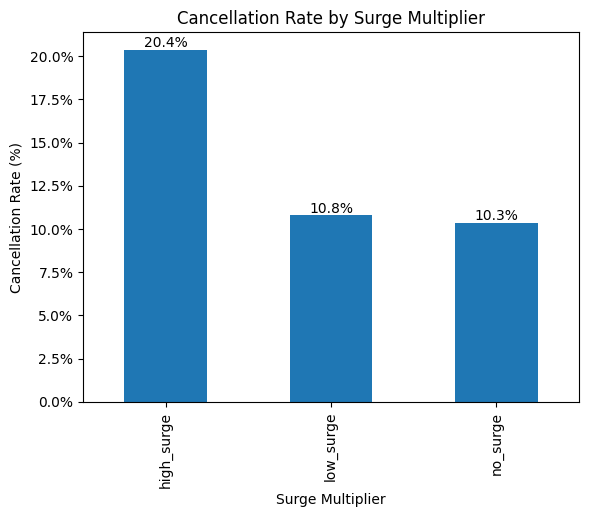

In [139]:
ax = df.groupby('surge_bucket')['is_cancelled'].mean().plot(kind='bar')

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Add labels on top
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Cancellation Rate by Surge Multiplier')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Surge Multiplier')

plt.show()

## encoding


In [140]:
df.drop(['ride_date', 'user_id','distance_km','day_of_week'], axis=1, inplace=True)

In [141]:
df.head()

,ride_hour,surge_multiplier,estimated_duration_min,driver_rating,city,event_type,user_segment,is_cancelled,is_peak_hour,is_weekend,surge_bucket,driver_seg,distance_bucket,high_risk_combo
0,16,1.00,23,4.4,Bangalore,normal,regular,0,0,0,no_surge,medium,"medium,",0
1,14,1.00,6,4.0,Mumbai,festival,regular,0,0,0,no_surge,medium,"medium,",0
2,8,1.43,52,4.4,Jaipur,rain,regular,0,1,0,low_surge,medium,long,0
3,0,1.00,22,4.7,Hyderabad,rain,regular,0,0,0,no_surge,high,"medium,",0
4,0,1.00,41,4.4,Jaipur,festival,regular,0,0,1,no_surge,medium,"medium,",0


In [142]:
category_cols= ['city', 'event_type', 'user_segment', 'surge_bucket', 'driver_seg', 'distance_bucket']

In [143]:
df = pd.get_dummies(df, columns=category_cols, drop_first=True).astype(int)

In [150]:
df.head()

,ride_hour,surge_multiplier,estimated_duration_min,driver_rating,is_cancelled,is_peak_hour,is_weekend,high_risk_combo,city_Coimbatore,city_Delhi,...,event_type_normal,event_type_rain,user_segment_power,user_segment_regular,surge_bucket_low_surge,surge_bucket_no_surge,driver_seg_low,driver_seg_medium,"distance_bucket_medium,",distance_bucket_long
0,16,1,23,4,0,0,0,0,0,0,...,1,0,0,1,0,1,0,1,1,0
1,14,1,6,4,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,1,0
2,8,1,52,4,0,1,0,0,0,0,...,0,1,0,1,1,0,0,1,0,1
3,0,1,22,4,0,0,0,0,0,0,...,0,1,0,1,0,1,0,0,1,0
4,0,1,41,4,0,0,1,0,0,0,...,0,0,0,1,0,1,0,1,1,0


In [151]:
X = df.drop('is_cancelled', axis=1)
y = df['is_cancelled']

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [160]:
model = LogisticRegression(
    max_iter=10000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [161]:
y_pred = model.predict(X_test)

In [162]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83     46736
           1       0.20      0.41      0.27      6808

    accuracy                           0.72     53544
   macro avg       0.55      0.59      0.55     53544
weighted avg       0.81      0.72      0.76     53544

